In [68]:
import ast
import math
import subprocess
import xml.etree.ElementTree as ET
from pathlib import Path

junit_path = Path("../test-results/pytest_report.xml")
out_svg = Path("../coverage-reports/python_test_duration_histogram.svg")

if not junit_path.exists():
  print(f"JUnit report not found at {junit_path}, skipping histogram generation")
  raise SystemExit(0)

def classname_to_nodeid(classname: str, test_name: str) -> str:
  if not classname:
    return test_name
  parts = classname.split(".")
  module_parts = []
  class_parts = []
  for p in parts:
    if not class_parts and p and p[0].islower():
      module_parts.append(p)
    else:
      class_parts.append(p)

  module_path = "/".join(module_parts) + ".py" if module_parts else ""
  tail = "::".join(class_parts + [test_name]) if class_parts else test_name
  return f"{module_path}::{tail}" if module_path else tail

def normalize_nodeid(nodeid: str) -> str:
  nid = (nodeid or "").strip().replace("\\", "/")
  if nid.startswith("./"):
    nid = nid[2:]
  if nid.startswith("python/"):
    nid = nid[len("python/"):]
  return nid

In [86]:
root = ET.parse(junit_path).getroot()
test_items = []
for tc in root.iter("testcase"):
  name = tc.get("name", "")
  classname = tc.get("classname", "")
  duration = float(tc.get("time", "0") or 0)
  nodeid = normalize_nodeid(classname_to_nodeid(classname, name))
  test_items.append((nodeid, duration))

if not test_items:
  print("No testcases found in JUnit XML, skipping histogram generation")
  raise SystemExit(0)

tests_dir = Path("../python/tests") if Path("../python/tests").exists() else Path("tests")
collect_target = str(tests_dir)

collect = subprocess.run(
  ["pytest", "--collect-only", "-q", "-m", "slow", collect_target],
  capture_output=True,
  text=True,
  check=False,
)
marked_slow_nodeids = {
  normalize_nodeid(line.strip())
  for line in collect.stdout.splitlines()
  if line.strip().startswith(("tests/", "python/tests/")) and "::" in line
}

slow_patterns = set()
for test_file in sorted(tests_dir.rglob("test_*.py")):
  try:
    src = test_file.read_text(encoding="utf-8")
    tree = ast.parse(src)
  except Exception:
    continue

  rel = normalize_nodeid(test_file.relative_to(tests_dir.parent).as_posix())

  def is_slow_decorator(dec: ast.AST) -> bool:
    text = ast.unparse(dec)
    has_marker = "pytest.mark.slow" in text
    has_env_guard = (
      "pytest.mark.skipif" in text
      and (
        "QDK_CHEMISTRY_RUN_SLOW_TESTS" in text
        or "_RUN_SLOW_TESTS" in text
      )
    )
    return has_marker or has_env_guard

  for node in tree.body:
    if isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef)) and node.name.startswith("test"):
      if any(is_slow_decorator(dec) for dec in node.decorator_list):
        slow_patterns.add((rel, node.name))

    if isinstance(node, ast.ClassDef):
      for child in node.body:
        if isinstance(child, (ast.FunctionDef, ast.AsyncFunctionDef)) and child.name.startswith("test"):
          if any(is_slow_decorator(dec) for dec in child.decorator_list):
            slow_patterns.add((rel, f"{node.name}::{child.name}"))

# Detect dynamic TestExampleScripts tests marked slow by check_example_requirements.
examples_dir_candidates = [
  Path("../docs/source/_static/examples/python"),
  Path("docs/source/_static/examples/python"),
]
examples_dir = next((p for p in examples_dir_candidates if p.exists()), None)
dynamic_docs_slow_count = 0
if examples_dir is not None:
  dynamic_tails = set()
  for example_file in sorted(examples_dir.glob("*.py")):
    try:
      content = example_file.read_text(encoding="utf-8")
    except Exception:
      continue

    if 'create("energy_estimator"' in content or "create('energy_estimator'" in content:
      dynamic_tails.add(f"TestExampleScripts::test_py_{example_file.stem}")

  for tail in dynamic_tails:
    slow_patterns.add(("tests/test_docs_examples.py", tail))
  dynamic_docs_slow_count = len(dynamic_tails)

env_or_marker_slow_nodeids = set(marked_slow_nodeids)
for nodeid, _ in test_items:
  file_part, sep, rest = nodeid.partition("::")
  if not sep:
    continue
  for pattern_file, pattern_tail in slow_patterns:
    if file_part == pattern_file and rest.startswith(pattern_tail):
      env_or_marker_slow_nodeids.add(nodeid)
      break

slow_nodeids = env_or_marker_slow_nodeids

slow_test_names = sorted(slow_nodeids)

durations = [d for _, d in test_items]
slow_durations = [d for nid, d in test_items if nid in slow_nodeids]

print(
  f"Detected slow tests: {len(slow_nodeids)} "
  f"(marker collect: {len(marked_slow_nodeids)}, ast patterns: {len(slow_patterns)}, "
  f"dynamic docs examples: {dynamic_docs_slow_count}, in report: {len(slow_durations)})"
)
print("Slow tests detected:")
if slow_test_names:
  for slow_name in slow_test_names:
    print(f" - {slow_name}")
else:
  print(" - none")

n = len(durations)

# Fixed duration bins
bin_labels = ["<1", "1-5", "5-10", "10-30", "30-60", ">60"]
bins = len(bin_labels)

def get_bin_index(v: float) -> int:
  if v < 1:
    return 0
  if v < 5:
    return 1
  if v < 10:
    return 2
  if v < 30:
    return 3
  if v < 60:
    return 4
  return 5

all_counts = [0] * bins
slow_counts = [0] * bins

def add_to_bins(values, counts):
  for v in values:
    counts[get_bin_index(v)] += 1

add_to_bins(durations, all_counts)
add_to_bins(slow_durations, slow_counts)
y_max = max(max(all_counts), 1)

width, height = 980, 560
left, right, top, bottom = 70, 30, 30, 70
plot_w = width - left - right
plot_h = height - top - bottom

def x_for_bin(i: int) -> float:
  return left + (i / bins) * plot_w

def y_for_count(c: int) -> float:
  return top + (1 - (c / y_max)) * plot_h

bar_slot = plot_w / bins
bar_w = bar_slot * 0.44

Detected slow tests: 5 (marker collect: 0, ast patterns: 5, dynamic docs examples: 3, in report: 5)
Slow tests detected:
 - tests/test_docs_examples.py::TestExampleScripts::test_py_energy_estimator
 - tests/test_docs_examples.py::TestExampleScripts::test_py_quickstart
 - tests/test_docs_examples.py::TestExampleScripts::test_py_release_notes_v1_1
 - tests/test_sample_workflow.py::test_qpe_stretched_n2
 - tests/test_sample_workflow.py::test_state_prep_energy


In [99]:
lines = []
lines.append(f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">')
lines.append('<rect x="0" y="0" width="100%" height="100%" fill="white"/>')

# Exclude first bin (<1s) from displayed histogram bars.
plot_labels = bin_labels[1:]
plot_all_counts = all_counts[1:]
plot_slow_counts = slow_counts[1:]
less_than_1s_count = all_counts[0] if all_counts else 0
display_bins = len(plot_labels)
y_scale_max = max(max(plot_all_counts), max(plot_slow_counts), 1)

# Add vertical padding between title/subtitle and plot area.
title_y = 20
subtitle_y = 40
plot_top = top + 28

lines.append(f'<text x="{left}" y="{title_y}" font-size="16" font-family="Arial">Pytest Duration Histogram</text>')
lines.append(
  f'<text x="{left}" y="{subtitle_y}" font-size="12" font-family="Arial">'
  f'Total tests: {n} | Slow tests: {len(slow_durations)} | Tests &lt; 1s: {less_than_1s_count} (not shown)'
  f'</text>'
)

def y_for_count(c: int) -> float:
  capped = min(c, y_scale_max)
  return plot_top + (1 - (capped / y_scale_max)) * plot_h

# Axes
lines.append(f'<line x1="{left}" y1="{plot_top + plot_h}" x2="{left + plot_w}" y2="{plot_top + plot_h}" stroke="black"/>')
lines.append(f'<line x1="{left}" y1="{plot_top}" x2="{left}" y2="{plot_top + plot_h}" stroke="black"/>')

# Y ticks (every 5)
y_tick_max = max(5, int(math.ceil(y_scale_max / 5.0) * 5))
for c in range(0, y_tick_max + 1, 5):
  y = plot_top + (1 - (c / y_tick_max)) * plot_h
  lines.append(f'<line x1="{left - 4}" y1="{y:.2f}" x2="{left}" y2="{y:.2f}" stroke="black"/>')
  lines.append(f'<text x="{left - 8}" y="{y + 4:.2f}" text-anchor="end" font-size="11" font-family="Arial">{c}</text>')

# X ticks (fixed duration buckets without first bucket)
bar_slot = plot_w / display_bins
bar_w = bar_slot * 0.62
for i, label in enumerate(plot_labels):
  x_center = left + (i + 0.5) * bar_slot
  label_xml = label.replace("<", "&lt;").replace(">", "&gt;")
  lines.append(f'<line x1="{x_center:.2f}" y1="{plot_top + plot_h}" x2="{x_center:.2f}" y2="{plot_top + plot_h + 4}" stroke="black"/>')
  lines.append(f'<text x="{x_center:.2f}" y="{plot_top + plot_h + 18}" text-anchor="middle" font-size="11" font-family="Arial">{label_xml}</text>')

# Bars centered on each tick: all tests (blue) and slow tests (orange, overlaid)
for i in range(display_bins):
  x_center = left + (i + 0.5) * bar_slot
  x_bar = x_center - (bar_w / 2)

  # All tests
  h_all = (min(plot_all_counts[i], y_tick_max) / y_tick_max) * plot_h
  y_all = plot_top + plot_h - h_all
  lines.append(
    f'<rect x="{x_bar:.2f}" y="{y_all:.2f}" width="{bar_w:.2f}" height="{h_all:.2f}" fill="#4C78A8" fill-opacity="0.60"/>'
  )

  # Slow tests
  h_slow = (min(plot_slow_counts[i], y_tick_max) / y_tick_max) * plot_h
  y_slow = plot_top + plot_h - h_slow
  lines.append(
    f'<rect x="{x_bar:.2f}" y="{y_slow:.2f}" width="{bar_w:.2f}" height="{h_slow:.2f}" fill="#F58518" fill-opacity="0.80"/>'
  )

# Labels and legend
lines.append(f'<text x="{left + plot_w / 2:.2f}" y="{height - 18}" text-anchor="middle" font-size="12" font-family="Arial">Duration bucket (seconds)</text>')
lines.append(f'<text x="18" y="{plot_top + plot_h / 2:.2f}" transform="rotate(-90 18,{plot_top + plot_h / 2:.2f})" text-anchor="middle" font-size="12" font-family="Arial">Number of tests</text>')
legend_x = left + plot_w - 200
legend_y = plot_top + 10
lines.append(f'<rect x="{legend_x}" y="{legend_y}" width="12" height="12" fill="#4C78A8" fill-opacity="0.60"/>')
lines.append(f'<text x="{legend_x + 18}" y="{legend_y + 10}" font-size="11" font-family="Arial">All tests</text>')
lines.append(f'<rect x="{legend_x + 90}" y="{legend_y}" width="12" height="12" fill="#F58518" fill-opacity="0.80"/>')
lines.append(f'<text x="{legend_x + 108}" y="{legend_y + 10}" font-size="11" font-family="Arial">Slow tests</text>')

lines.append('</svg>')
out_svg.write_text("\n".join(lines), encoding="utf-8")
print(f"Wrote histogram to {out_svg}")

# Write Top-100 longest tests table (with slow marker) for summaries.
top_md = Path("../coverage-reports/python_test_top200.md")
top_rows = sorted(test_items, key=lambda item: item[1], reverse=True)[:100]
md_lines = [
  "### Top 100 Longest Python Tests",
  "",
  "| Rank | Test | Duration (s) | Slow |",
  "|---:|---|---:|:---:|",
]
for i, (nodeid, duration) in enumerate(top_rows, start=1):
  safe_nodeid = nodeid.replace("|", "\\|")
  slow_flag = "Yes" if nodeid in slow_nodeids else "No"
  md_lines.append(f"| {i} | `{safe_nodeid}` | {duration:.1f} | {slow_flag} |")
top_md.write_text("\n".join(md_lines) + "\n", encoding="utf-8")
print(f"Wrote top durations table to {top_md}")

Wrote histogram to ../coverage-reports/python_test_duration_histogram.svg
Wrote top durations table to ../coverage-reports/python_test_top200.md


In [92]:
durations_less1min = sorted([d for d in durations if d < 1.0], reverse=True)
durations_plus1min = sorted([d for d in durations if d >= 1.0], reverse=True)
print(f"{len(durations_plus1min)} tests of {len(durations)} took 1 second or more.")
print(f"( {len(durations):4d} ) Total duration      = {sum(durations):6.1f} s\n"
      f"( {len(durations_less1min):4d} ) Fast tests (< 1 s)  = {sum(durations_less1min):6.1f} s\n"
      f"( {len(durations_plus1min):4d} ) Slow tests (>= 1 s) = {sum(durations_plus1min):6.1f} s"
)

86 tests of 1781 took 1 second or more.
( 1781 ) Total duration      = 1674.3 s
( 1695 ) Fast tests (< 1 s)  =   48.1 s
(   86 ) Slow tests (>= 1 s) = 1626.2 s


Histogram path: ../coverage-reports/python_test_duration_histogram.svg


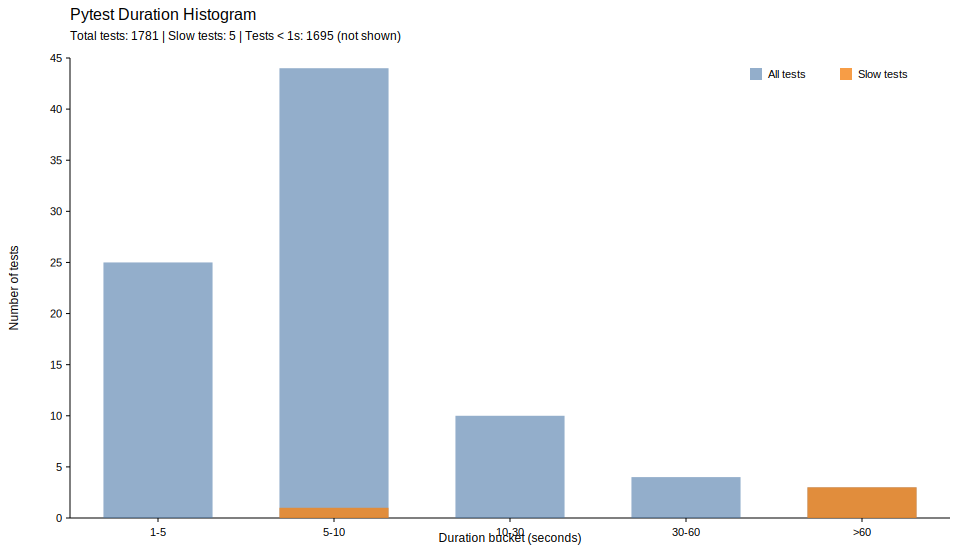

Top-200 table path: ../coverage-reports/python_test_top200.md


### Top 100 Longest Python Tests

| Rank | Test | Duration (s) | Slow |
|---:|---|---:|:---:|
| 1 | `tests/test_sample_workflow.py::test_qpe_stretched_n2` | 396.9 | Yes |
| 2 | `tests/test_sample_workflow.py::test_state_prep_energy` | 291.7 | Yes |
| 3 | `tests/test_docs_examples.py::TestExampleScripts::test_py_quickstart` | 246.8 | Yes |
| 4 | `tests/test_stability.py::TestStabilityChecker::test_stability_rhf_water[qdk-m06-2x-0.2628966726-0.2101707965]` | 44.7 | No |
| 5 | `tests/test_stability.py::TestStabilityWorkflow::test_workflow_n2_uhf_instability[qdk-m06-2x--109.24696612470082]` | 42.8 | No |
| 6 | `tests/test_sample_workflow_qiskit.py::test_qiskit_iqpe_trotter` | 36.0 | No |
| 7 | `tests/test_sample_workflow_sci.py::test_sample_sci_workflow_macis_asci_autocas_with_limits` | 32.4 | No |
| 8 | `tests/test_stability.py::TestStabilityChecker::test_stability_rhf_water[qdk-pbe-0.2359001392-0.1777736962]` | 29.8 | No |
| 9 | `tests/test_stability.py::TestStabilityWorkflow::test_workflow_n2_rhf_both_instability[qdk-pbe--109.09282137913918]` | 25.8 | No |
| 10 | `tests/test_sample_workflow_qiskit.py::test_qiskit_iqpe_model_hamiltonian` | 23.2 | No |
| 11 | `tests/test_stability.py::TestStabilityChecker::test_stability_uhf_o2[qdk-m06-2x--150.14208965731274-0.1972664302]` | 19.9 | No |
| 12 | `tests/test_docs_examples.py::TestExampleScripts::test_py_phase_estimation` | 16.9 | No |
| 13 | `tests/test_stability.py::TestStabilityChecker::test_stability_uhf_water_plus[qdk-pbe-0.0788074855]` | 14.8 | No |
| 14 | `tests/test_stability.py::TestStabilityChecker::test_stability_uhf_o2[qdk-pbe--150.06573508243736-0.228479663]` | 13.8 | No |
| 15 | `tests/test_sample_workflow.py::test_factory_list` | 13.4 | No |
| 16 | `tests/test_docs_examples.py::TestExampleScripts::test_py_mcscf` | 13.0 | No |
| 17 | `tests/test_stability.py::TestStabilityWorkflow::test_workflow_n2_uhf_instability[pyscf-m06-2x--109.24696794801413]` | 11.4 | No |
| 18 | `tests/test_sample_workflow_pennylane.py::test_pennylane_qpe_no_trotter` | 9.4 | No |
| 19 | `tests/test_stability.py::TestStabilityWorkflow::test_workflow_n2_rhf_external_instability[qdk-pbe--109.30399851151739]` | 9.4 | No |
| 20 | `tests/test_docs_examples.py::TestExampleScripts::test_py_basis_set` | 8.6 | No |
| 21 | `tests/test_pyscf_plugin.py::TestPyscfPlugin::test_pyscf_fciwrapper_casci_triplet` | 8.4 | No |
| 22 | `tests/test_sample_workflow_qiskit.py::test_qiskit_iqpe_no_trotter` | 8.4 | No |
| 23 | `tests/test_docs_examples.py::TestExampleScripts::test_py_circuit` | 7.8 | No |
| 24 | `tests/test_docs_examples.py::TestExampleScripts::test_py_circuit_executor` | 7.8 | No |
| 25 | `tests/test_sample_workflow_sci.py::test_sample_sci_workflow_scenarios[valence_defaults]` | 7.8 | No |
| 26 | `tests/test_sample_workflow_openfermion.py::test_openfermion_molecular_hamiltonian_jordan_wigner` | 7.6 | No |
| 27 | `tests/test_docs_examples.py::TestExampleScripts::test_py_qubit_mapper` | 7.4 | No |
| 28 | `tests/test_docs_examples.py::TestExampleScripts::test_py_dynamical_correlation` | 7.4 | No |
| 29 | `tests/test_docs_examples.py::TestExampleScripts::test_py_state_preparation` | 7.2 | No |
| 30 | `tests/test_sample_workflow_sci.py::test_sample_sci_workflow_scenarios[valence_overrides]` | 7.2 | No |
| 31 | `tests/test_docs_examples.py::TestExampleScripts::test_py_active_space_selector` | 7.1 | No |
| 32 | `tests/test_docs_examples.py::TestExampleScripts::test_py_hamiltonian` | 7.0 | No |
| 33 | `tests/test_docs_examples.py::TestExampleScripts::test_py_ansatz` | 6.9 | No |
| 34 | `tests/test_sample_workflow_rdkit.py::test_sample_rdkit_geometry` | 6.9 | No |
| 35 | `tests/test_docs_examples.py::TestExampleScripts::test_py_circuit_mapper` | 6.9 | No |
| 36 | `tests/test_docs_examples.py::TestExampleScripts::test_py_settings` | 6.8 | No |
| 37 | `tests/test_docs_examples.py::TestExampleScripts::test_py_factory_pattern` | 6.8 | No |
| 38 | `tests/test_docs_examples.py::TestExampleScripts::test_py_scf_solver` | 6.8 | No |
| 39 | `tests/test_docs_examples.py::TestExampleScripts::test_py_design_principles` | 6.7 | No |
| 40 | `tests/test_sample_workflow_sci.py::test_sample_sci_workflow_scenarios[valence_autocas_fallback]` | 6.7 | No |
| 41 | `tests/test_docs_examples.py::TestExampleScripts::test_py_hamiltonian_unitary_builder` | 6.6 | No |
| 42 | `tests/test_docs_examples.py::TestExampleScripts::test_py_energy_estimator` | 6.6 | Yes |
| 43 | `tests/test_sample_workflow_sci.py::test_sample_sci_workflow_scenarios[valence_autocas_threshold]` | 6.5 | No |
| 44 | `tests/test_docs_examples.py::TestExampleScripts::test_py_lattice_graph` | 6.5 | No |
| 45 | `tests/test_docs_examples.py::TestExampleScripts::test_py_pmc` | 6.5 | No |
| 46 | `tests/test_docs_examples.py::TestExampleScripts::test_py_localizer` | 6.4 | No |
| 47 | `tests/test_docs_examples.py::TestExampleScripts::test_py_interfaces` | 6.4 | No |
| 48 | `tests/test_docs_examples.py::TestExampleScripts::test_py_model_hamiltonians` | 6.3 | No |
| 49 | `tests/test_docs_examples.py::TestExampleScripts::test_py_stability_checker_workflow` | 6.3 | No |
| 50 | `tests/test_docs_examples.py::TestExampleScripts::test_py_serialization` | 6.3 | No |
| 51 | `tests/test_docs_examples.py::TestExampleScripts::test_py_structure` | 6.3 | No |
| 52 | `tests/test_docs_examples.py::TestExampleScripts::test_py_mc_calculator` | 6.2 | No |
| 53 | `tests/test_docs_examples.py::TestExampleScripts::test_py_pauli_operator` | 6.2 | No |
| 54 | `tests/test_docs_examples.py::TestExampleScripts::test_py_qpe_result` | 6.1 | No |
| 55 | `tests/test_docs_examples.py::TestExampleScripts::test_py_wavefunction_container` | 6.1 | No |
| 56 | `tests/test_docs_examples.py::TestExampleScripts::test_py_hamiltonian_constructor` | 6.1 | No |
| 57 | `tests/test_docs_examples.py::TestExampleScripts::test_py_orbitals` | 6.0 | No |
| 58 | `tests/test_energy_estimator.py::test_estimator_run_4e4o[qdk-sparse-state]` | 5.9 | No |
| 59 | `tests/test_docs_examples.py::TestExampleScripts::test_py_custom_plugin` | 5.9 | No |
| 60 | `tests/test_stability.py::TestStabilityWorkflow::test_workflow_n2_rhf_both_instability[pyscf-pbe--109.09282114654889]` | 5.3 | No |
| 61 | `tests/test_stability.py::TestStabilityChecker::test_stability_rhf_f_minus[qdk-m06-2x-1.280285-1.004914]` | 5.3 | No |
| 62 | `tests/test_stability.py::TestStabilityChecker::test_stability_rhf_water[pyscf-m06-2x-0.262895-0.2101587728]` | 4.4 | No |
| 63 | `tests/test_stability.py::TestStabilityChecker::test_stability_uhf_o2[pyscf-m06-2x--150.14208614693325-0.19723409]` | 3.9 | No |
| 64 | `tests/test_scf.py::TestScfSolver::test_scf_solver_water_triplet_gdm` | 2.9 | No |
| 65 | `tests/test_phase_estimation_iterative.py::test_iterative_phase_estimation_second_non_commuting_example` | 2.9 | No |
| 66 | `tests/test_stability.py::TestStabilityChecker::test_stability_uhf_water_plus[pyscf-pbe-0.0787946207]` | 2.7 | No |
| 67 | `tests/test_stability.py::TestStabilityChecker::test_stability_rhf_water[pyscf-pbe-0.2358971641-0.1777711776]` | 2.5 | No |
| 68 | `tests/test_stability.py::TestStabilityChecker::test_stability_uhf_o2[pyscf-pbe--150.0657335489032-0.228479663]` | 2.3 | No |
| 69 | `tests/test_utils_pauli_matrix.py::TestPauliToSparseMatrix::test_12qubit_5terms_sparse_matches_pauli_mat` | 2.3 | No |
| 70 | `tests/test_stability.py::TestStabilityWorkflow::test_workflow_n2_rhf_external_instability[pyscf-pbe--109.30399919130937]` | 2.2 | No |
| 71 | `tests/test_mcscf.py::TestMCSCF::test_n2_6_6_ccpvdz_casscf` | 1.8 | No |
| 72 | `tests/test_utils_pauli_matrix.py::TestPauliToSparseMatrix::test_large_qubit_construction[24]` | 1.8 | No |
| 73 | `tests/test_pyscf_plugin.py::TestPyscfPlugin::test_pyscf_mcscf_singlet` | 1.7 | No |
| 74 | `tests/test_pyscf_plugin.py::TestPyscfPlugin::test_pyscf_water_er_localization_def2svp` | 1.7 | No |
| 75 | `tests/test_scf.py::TestScfSolver::test_scf_solver_oxygen_atom_charged_doublet_gdm` | 1.6 | No |
| 76 | `tests/test_pyscf_plugin.py::TestPyscfPlugin::test_pyscf_fciwrapper_casscf_singlet` | 1.6 | No |
| 77 | `tests/test_mcscf.py::TestMCSCF::test_o2_6_6_ccpvdz_casscf_triplet` | 1.6 | No |
| 78 | `tests/test_pyscf_plugin.py::TestPyscfPlugin::test_pyscf_mcscf_triplet` | 1.6 | No |
| 79 | `tests/test_pyscf_plugin.py::TestPyscfPlugin::test_pyscf_fciwrapper_casscf_triplet` | 1.6 | No |
| 80 | `tests/test_phase_estimation_iterative.py::test_iterative_and_traditional_match_on_four_qubits` | 1.5 | No |
| 81 | `tests/test_energy_estimator.py::test_estimator_run_4e4o[qdk-full-state]` | 1.5 | No |
| 82 | `tests/test_interop_qiskit_state_prep_energy_validation.py::test_energy_agreement_between_state_prep_methods` | 1.4 | No |
| 83 | `tests/test_interop_qiskit_state_prep_energy_validation.py::test_sparse_isometry_gf2x_circuit_efficiency` | 1.2 | No |
| 84 | `tests/test_scf.py::TestScfSolver::test_scf_solver_oxygen_atom_history_size_limit_gdm` | 1.2 | No |
| 85 | `tests/test_scf.py::TestScfSolver::test_scf_solver_oxygen_atom_gdm` | 1.2 | No |
| 86 | `tests/test_state_preparation.py::test_regular_isometry_state_prep` | 1.1 | No |
| 87 | `tests/test_euler_integrator.py::test_euler_integrator_eigenvalue_remains_constant` | 0.9 | No |
| 88 | `tests/test_pyscf_plugin.py::TestPyscfPlugin::test_pyscf_o2_fb_localization_def2svp_uhf` | 0.9 | No |
| 89 | `tests/test_phase_estimation_iterative.py::test_iterative_and_traditional_results_match` | 0.9 | No |
| 90 | `tests/test_scf.py::TestScfSolver::test_scf_solver_oxygen_atom_one_diis_step_gdm` | 0.8 | No |
| 91 | `tests/test_interop_qiskit_phase_estimation_standard.py::test_traditional_phase_estimation_four_qubit_problem` | 0.8 | No |
| 92 | `tests/test_pyscf_plugin.py::TestPyscfPlugin::test_pyscf_o2_er_localization_def2svp_rohf` | 0.8 | No |
| 93 | `tests/test_energy_estimator.py::test_estimator_mixed_identity_and_pauli_terms` | 0.7 | No |
| 94 | `tests/test_stability.py::TestStabilityChecker::test_stability_rhf_f_minus[pyscf-m06-2x-1.2802832042-1.0049090209]` | 0.7 | No |
| 95 | `tests/test_qdk_qubit_mapper.py::TestBravyiKitaevTreeMapper::test_bk_tree_clifford_algebra` | 0.7 | No |
| 96 | `tests/test_active_space.py::TestWavefunctionBasedActiveSpaceSelector::test_autocas_selection` | 0.7 | No |
| 97 | `tests/test_stability.py::TestStabilityWorkflow::test_workflow_n2_rhf_both_instability[qdk-hf--108.606721153932]` | 0.7 | No |
| 98 | `tests/test_pyscf_plugin.py::TestPyscfPlugin::test_pyscf_o2_er_localization_def2svp_uhf` | 0.7 | No |
| 99 | `tests/test_pyscf_plugin.py::TestPyscfPlugin::test_pyscf_uccsd_o2_triplet_def2svp` | 0.7 | No |
| 100 | `tests/test_qdk_interpreter_init.py::test_qdk_interpreter_init_with_target_profile` | 0.6 | No |


In [100]:
from IPython.display import Markdown, SVG, display
from pathlib import Path

hist_path = Path("../coverage-reports/python_test_duration_histogram.svg")
top200_path = Path("../coverage-reports/python_test_top200.md")

print(f"Histogram path: {hist_path}")
if hist_path.exists():
  display(SVG(filename=str(hist_path)))
else:
  print("Histogram file not found.")

print(f"Top-200 table path: {top200_path}")
if top200_path.exists():
  display(Markdown(top200_path.read_text(encoding="utf-8")))
else:
  print("Top-200 table file not found.")

In [98]:
from IPython.display import Markdown, display

thresholds = [10, 20, 30, 40, 60]

def to_min_sec(seconds: float) -> str:
  total = int(round(seconds))
  minutes, secs = divmod(total, 60)
  return f"{minutes}:{secs:02d}"

if not durations:
  display(Markdown("No durations available."))
else:
  total_runtime = sum(durations)
  total_tests = len(durations)

  sorted_thresholds = sorted(thresholds, reverse=True)
  tests_by_threshold = {
    th: {
      nodeid
      for nodeid, duration in test_items
      if duration > th
    }
    for th in sorted_thresholds
  }

  md_lines = [
    "### Runtime Savings If Long Tests Are Classified As Slow",
    "",
    f"Total tests: **{total_tests}**  ",
    f"Total runtime: **{to_min_sec(total_runtime)}**",
    "",
    "| Threshold (s) | Tests moved to slow | % of tests | Time moved to slow (m:ss) | % runtime saved |",
    "|---:|---:|---:|---:|---:|",
  ]

  for threshold in sorted_thresholds:
    moved = [d for d in durations if d > threshold]
    moved_count = len(moved)
    moved_time = sum(moved)
    pct_tests = (100.0 * moved_count / total_tests) if total_tests else 0.0
    pct_time = (100.0 * moved_time / total_runtime) if total_runtime else 0.0

    md_lines.append(
      f"| {threshold} | {moved_count} | {pct_tests:.1f}% | {to_min_sec(moved_time)} | {pct_time:.1f}% |"
    )

  md_lines.append("")
  md_lines.append("### Tests Added At Each Threshold")
  md_lines.append("")

  for i, threshold in enumerate(sorted_thresholds):
    current = tests_by_threshold[threshold]
    previous = tests_by_threshold[sorted_thresholds[i - 1]] if i > 0 else set()
    added = sorted(current - previous)

    md_lines.append(f"#### > {threshold} s ({len(added)} added)")
    if added:
      for nodeid in added:
        md_lines.append(f"- `{nodeid}`")
    else:
      md_lines.append("- None")
    md_lines.append("")

  md_lines.append("Assumption: time moved to slow is the runtime removed from default test runs.")

  display(Markdown("\n".join(md_lines)))

### Runtime Savings If Long Tests Are Classified As Slow

Total tests: **1781**  
Total runtime: **27:54**

| Threshold (s) | Tests moved to slow | % of tests | Time moved to slow (m:ss) | % runtime saved |
|---:|---:|---:|---:|---:|
| 60 | 3 | 0.2% | 15:35 | 55.9% |
| 40 | 5 | 0.3% | 17:03 | 61.1% |
| 30 | 7 | 0.4% | 18:11 | 65.2% |
| 20 | 10 | 0.6% | 19:30 | 69.9% |
| 10 | 17 | 1.0% | 21:13 | 76.1% |

### Tests Added At Each Threshold

#### > 60 s (3 added)
- `tests/test_docs_examples.py::TestExampleScripts::test_py_quickstart`
- `tests/test_sample_workflow.py::test_qpe_stretched_n2`
- `tests/test_sample_workflow.py::test_state_prep_energy`

#### > 40 s (2 added)
- `tests/test_stability.py::TestStabilityChecker::test_stability_rhf_water[qdk-m06-2x-0.2628966726-0.2101707965]`
- `tests/test_stability.py::TestStabilityWorkflow::test_workflow_n2_uhf_instability[qdk-m06-2x--109.24696612470082]`

#### > 30 s (2 added)
- `tests/test_sample_workflow_qiskit.py::test_qiskit_iqpe_trotter`
- `tests/test_sample_workflow_sci.py::test_sample_sci_workflow_macis_asci_autocas_with_limits`

#### > 20 s (3 added)
- `tests/test_sample_workflow_qiskit.py::test_qiskit_iqpe_model_hamiltonian`
- `tests/test_stability.py::TestStabilityChecker::test_stability_rhf_water[qdk-pbe-0.2359001392-0.1777736962]`
- `tests/test_stability.py::TestStabilityWorkflow::test_workflow_n2_rhf_both_instability[qdk-pbe--109.09282137913918]`

#### > 10 s (7 added)
- `tests/test_docs_examples.py::TestExampleScripts::test_py_mcscf`
- `tests/test_docs_examples.py::TestExampleScripts::test_py_phase_estimation`
- `tests/test_sample_workflow.py::test_factory_list`
- `tests/test_stability.py::TestStabilityChecker::test_stability_uhf_o2[qdk-m06-2x--150.14208965731274-0.1972664302]`
- `tests/test_stability.py::TestStabilityChecker::test_stability_uhf_o2[qdk-pbe--150.06573508243736-0.228479663]`
- `tests/test_stability.py::TestStabilityChecker::test_stability_uhf_water_plus[qdk-pbe-0.0788074855]`
- `tests/test_stability.py::TestStabilityWorkflow::test_workflow_n2_uhf_instability[pyscf-m06-2x--109.24696794801413]`

Assumption: time moved to slow is the runtime removed from default test runs.